In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import qiskit
from functools import reduce
import time
import pickle


In [46]:
def pauli_str_to_unitary(pstr):
    def char_to_pauli(c):
        if c == "I":
            return np.eye(2)
        elif c == "X":
            return np.array([[0, 1], [1, 0]])
        elif c == "Y":
            return np.array([[0, -1j], [1j, 0]])
        elif c == "Z":
            return np.array([[1, 0], [0, -1]])
        else:
            raise ValueError(f"Invalid Pauli character: {c}")
    
    return reduce(np.kron, [char_to_pauli(c) for c in pstr], np.array([[1]]))

In [47]:
def spin_chain_H(n, J=1, g=1, type="transverse"):
    d = 2**n
    if type == "transverse":
        Hzz, Hx = np.zeros((d, d)), np.zeros((d, d))
        for i in range(n):
            if i < n-1:
                pstr = list("I"*n)
                pstr[i] = pstr[i+1] = "Z"
                Hzz += pauli_str_to_unitary(pstr)
            
            pstr = list("I"*n)
            pstr[i] = "X"
            Hx += pauli_str_to_unitary(pstr)

        Hzz *= -J
        Hx *= -J*g # h = -J*g
        H = Hzz + Hx

    return H, [Hzz, Hx]

In [48]:
def rand_prod_state(n):
    def rand_state():
        return qiskit.quantum_info.random_statevector(2)

    return reduce(np.kron, [rand_state() for _ in range(n)], np.array(1))

In [49]:
def expect(state, H):
    if state.ndim == 1:
        res = state.conj().T @ H @ state
    else:
        rho = state
        res = np.trace(rho @ H)
    
    assert np.isclose(res.imag, 0)
    return res.real # real-valued observables

def outer(state):
    psi = state.reshape(-1, 1)
    return psi @ psi.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho-sigma))) / 2

def spin_cov(rho, spin_ind):
    n = int(np.log2(rho.shape[0]))
    pstr = list('I'*n)
    pstr[spin_ind] = 'X'
    expect_Xi = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind+1] = 'X'
    expect_XiXiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind] = 'I'
    expect_Xiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    spin_cov = expect_XiXiplus1 - expect_Xi*expect_Xiplus1
    return spin_cov

In [50]:
gcauchy_pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4)

def sample_gcauchy(beta, M=1):
    cs = []
    # pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4) ~ C_{1/sqrt2}^4
    thresh = (1+np.sqrt(5))/2 # sup u of pdf(u)/cauchypdf(u) = golden ratio
    while len(cs) < M:
        c = scipy.stats.cauchy.rvs()
        u = scipy.stats.uniform.rvs()
        h = (1+c**2)/(1+(c/np.sqrt(2))**4)
        if u < h/thresh:
            cs.append(c)

    return beta*(np.array(cs) if M > 1 else cs[0])

def gcauchy_pdf(beta):
    pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4)
    return lambda u: 1/beta * pdf(u/beta)

In [51]:
def _sinc_no_pi(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isclose(x, 0.0), 1.0, np.sin(x) / x)


def sdelta_pdf(delta):
    if delta <= 0:
        raise ValueError("delta must be positive")

    def pdf(t):
        x = delta * np.asarray(t, dtype=float) / 4.0
        vals = (3.0 * delta) / (8.0 * np.pi) * _sinc_no_pi(x) ** 4
        return float(vals) if np.ndim(t) == 0 else vals

    return pdf


def sample_sdelta(delta, M=1, envelope=6.5):
    if delta <= 0:
        raise ValueError("delta must be positive")
    if M < 1:
        raise ValueError("M must be >= 1")

    # Rejection sampling for S_1 using a standard Cauchy proposal, then scale by 1/delta.
    accepted = []
    while len(accepted) < M:
        batch = max(2 * (M - len(accepted)), 1)
        y = scipy.stats.cauchy.rvs(size=batch)
        u = scipy.stats.uniform.rvs(size=batch)

        target = (3.0 / (8.0 * np.pi)) * _sinc_no_pi(y / 4.0) ** 4
        proposal = 1.0 / (np.pi * (1.0 + y ** 2))
        keep = u < (target / (envelope * proposal))

        if np.any(keep):
            accepted.extend((y[keep] / delta).tolist())

    samples = np.array(accepted[:M])
    return samples if M > 1 else samples[0]

In [52]:
class Hamiltonian:
    def __init__(self, H, Hs=[], steps=0, order=1, dynamic_steps=False, max_dt=1.0, dynamic_order=2):
        if steps == 0:
            Hs = [H]
            steps = 1
            order = 1
        
        self.H = H
        self.Hs = Hs 
        self.n = self.Hs[0].shape[0]
        self.steps = steps
        self.order = order
        self.dynamic_steps = dynamic_steps
        self.max_dt = max_dt
        self.dynamic_order = dynamic_order

        self.Us = []
        self.Ds = []
        self.lams = []
        for Hi in self.Hs:
            eigenvals, eigenvecs = np.linalg.eigh(Hi)
            self.Us.append(eigenvecs)
            self.Ds.append(np.diag(eigenvals))
            self.lams.append(eigenvals)
        
        eigenvals, eigenvecs = np.linalg.eigh(self.H)
        self.U = eigenvecs
        self.D = np.diag(eigenvals)
        self.lam = eigenvals
        self.ground = eigenvecs[:, 0]
    
    
    # e^{alpha H_i}
    def term(self, i, alpha, method="fast"):
        if "direct" in method:
            return scipy.linalg.expm(self.Hs[i] * alpha)
        elif "fast" in method:
            return self.Us[i] @ np.diag(np.exp(self.lams[i] * alpha)) @ self.Us[i].conj().T
        else:
            raise ValueError(f"Invalid method: {method}")
    
    # e^{alpha H_i} via a trotter formula
    def trotter(self, alpha, method="fast"):
        def S(x, o):
            assert o > 0 and (o == 1 or o%2 == 0)
            init = np.identity(self.n)
            if o == 1:
                terms = [self.term(i, x, method=method) for i in range(len(self.Hs))]
                return reduce(lambda A, B: A @ B, terms, init) 
            elif o == 2:
                terms = [self.term(i, x/2, method=method) for i in range(len(self.Hs))]
                return reduce(lambda A, B: A @ B, terms, init) @ reduce(lambda A, B : B @ A, terms, init)
            else:
                p = 1.0 / (4 - 4**(1.0 / (o - 1)))
                return S(p*x, o - 2) @ S((1-2*p)*x, o-2) @ S(p*x, o-2)

        steps = self.steps
        order = self.order
        if self.dynamic_steps:
            steps = self.steps*max(1, int(np.ceil(np.abs(alpha) / self.max_dt)))
            print(steps)
            order = self.dynamic_order

        res = np.linalg.matrix_power(S(alpha/steps, order), steps)
        return res
    
    def ITE(self, beta, method="fast"):        
        return self.trotter(-beta, method=method)

    def RTE(self, t, method="fast"):
        return self.trotter(-1j * t, method=method)
    
    def iITE(self, state, beta, method="fast"):
        psi_ = self.ITE(beta, method=method) @ state
        psi = psi_ / np.linalg.norm(psi_)
        return psi

    def iITE_rand_iRTE(self, state, beta, M = 1000, sample=sample_gcauchy, pdf=gcauchy_pdf, method="fast", **kwargs):
        method2 = "direct" if "direct" in method else "fast"
        psi = self.iITE(state, beta, method=method2)

        if method == "direct":
            samples = np.array([sample() for _ in range(M)])
            states = [self.RTE(t, method=method2) @ psi for t in samples]
            rho = sum([outer(s) for s in states]) / M
        elif method == "fast":
            # TODO: add trotterization in fast sample case
            assert len(self.Hs) == 1
            samples = np.array([sample() for _ in range(M)])
            c = self.U.conj().T @ psi
            phases = np.exp(-1j * np.outer(self.lam, samples))  # (n, M): phase factors exp(-i λ_i t_j)
            c_t = c[:, None] * phases                            # (n, M): c * exp(-i λ t_j)
            psi_t = self.U @ c_t                                  # (n, M): ψ_t = U @ c_t
            rho = psi_t @ psi_t.conj().T / M            # (1/M) Σ_j |ψ_t_j⟩⟨ψ_t_j|
        elif method == "integrate": 
            # \int dt p(t) e^{-iHt} e^{-\beta H} \rho_0 e^{-\beta H} e^{iHt} 
            # \int dt p(t) U e^{(-\beta-it) lam} U^dagger \rho_0 U e^{(-beta+it) lam} U^dagger
            # rho_0 = outer(psi)
            middle = [
                (np.identity(self.n) if i == 0 else self.Us[i-1].conj().T)
                @
                (np.identity(self.n) if i == len(self.Hs) else self.Us[i])
                for i in range(len(self.Hs)+1)
            ] # middle[i] = U[i] or U[i-1]^dagger U[i] or U[n-1].conj().T
            
            def integrand(t):
                psi_prime = self.RTE(t, method="fast") @ psi
                return pdf(t) * outer(psi_prime)
            
            rho = scipy.integrate.quad_vec(integrand, -np.inf, np.inf, **kwargs)[0]
        else:
            raise ValueError(f"Invalid method: {method}")
        
        return rho
    

In [53]:
# hamil = Hamiltonian(spin_chain_H(4)[0])

# psi0 = rand_prod_state(4)
# beta = 1

# # Time each method averaged over 10 runs
# times_integrate = []
# times_direct = []
# times_fast = []

# for _ in range(10):
#     start = time.time()
#     rho = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), pdf=gcauchy_pdf(beta), method="integrate", epsrel=1e-4)
#     times_integrate.append(time.time() - start)
        
#     start = time.time()
#     rho_2 = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), sample=lambda: sample_gcauchy(beta), method="direct") 
#     times_direct.append(time.time() - start)
    
#     start = time.time()
#     rho_3 = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), sample=lambda: sample_gcauchy(beta), method="fast")
#     times_fast.append(time.time() - start)

# print(f"Average times:")
# print(f"Integrate: {np.mean(times_integrate):.3f}s")
# print(f"Direct: {np.mean(times_direct):.3f}s") 
# print(f"Fast: {np.mean(times_fast):.3f}s")


In [54]:
len(hamil.Hs)

2

In [55]:
n = 4
g = 1.4
J = 1.0
omega = 1.0
excited_ind = 0
H, Hs = spin_chain_H(n, J=J, g=g)
T = 1

psi0s = [rand_prod_state(n) for _ in range(T)]
memory = {}

In [59]:
# # Excited
# hamilH = Hamiltonian(H)
# omega = hamilH.lam[excited_ind] - (hamilH.lam[excited_ind] - hamilH.lam[excited_ind-1])*0.4
# Hp = H - omega * np.eye(2**n)
# Hp = Hp @ Hp 
# hamil = Hamiltonian(Hp)

# steps, order = 0, 0 # Standard
steps, order = 50, 2 # custom
# steps, order = int(1e3), 1 # Trotterized
# steps, order = int(1e3), 2 # Trotterized
# steps, order = int(1e3), 4
# steps, order = int(1e3), 6
hamil = Hamiltonian(H, Hs, steps=steps, order=order)

Delta = hamil.lam[1] - hamil.lam[0]
spin_ind = 2

betas = np.linspace(0, 10, 20+1)[1:]
data = {'rhos': dict(), 'energies': dict(), 'spincov': dict(), 'trd': dict()}

method_names = ['iITE', 'iITE_rand_iRTE']
methods = [
    lambda *args: outer(hamil.iITE(*args, method="direct")),
    lambda psi0, beta: hamil.iITE_rand_iRTE(
        psi0, beta, M=int(1e3),
        sample=stats.norm(loc=0, scale=np.sqrt(2*beta/Delta)).rvs,
        pdf=stats.norm(loc=0, scale=np.sqrt(2*beta/Delta)).pdf,
        # sample=lambda: sample_sdelta(Delta),
        # pdf=sdelta_pdf(Delta),
        # sample=lambda: sample_gcauchy(beta),
        # pdf=gcauchy_pdf(beta),
        method="integrate",
        # method="direct",
        epsrel=1e-6
    )
]
aux = "normal"

for mi, m in enumerate(methods):
    print(f"Method: {mi}")
    mn = method_names[mi]
    method = methods[mi]

    for psi0 in psi0s:
        d = {k: [] for k in data}
        for beta in betas:
            print(f"beta: {beta}")
            rho = method(psi0, beta)
            d['rhos'].append(rho)

            d['energies'].append(expect(rho, H))
            d['trd'].append(trdist(rho, outer(hamil.U[:,excited_ind])))

            d['spincov'].append(spin_cov(rho, spin_ind))
        
        for k in data:
            if mn not in data[k]: data[k][mn] = []
            data[k][mn].append(d[k])

    for k in data: data[k][mn] = np.array(data[k][mn])

memory[(steps, order, aux)] = data


Method: 0
beta: 0.5
beta: 1.0
beta: 1.5
beta: 2.0
beta: 2.5
beta: 3.0
beta: 3.5
beta: 4.0
beta: 4.5
beta: 5.0
beta: 5.5
beta: 6.0
beta: 6.5
beta: 7.0
beta: 7.5
beta: 8.0
beta: 8.5
beta: 9.0
beta: 9.5
beta: 10.0
Method: 1
beta: 0.5
beta: 1.0
beta: 1.5
beta: 2.0
beta: 2.5
beta: 3.0
beta: 3.5
beta: 4.0
beta: 4.5
beta: 5.0
beta: 5.5
beta: 6.0
beta: 6.5
beta: 7.0
beta: 7.5
beta: 8.0
beta: 8.5
beta: 9.0
beta: 9.5
beta: 10.0


In [60]:
import pickle

filename = f"data_n{n}_g{g}_J{J}_exact.pkl"
with open(filename, "wb") as f:
    pickle.dump(data, f)

In [61]:
def energy_plot(ax, data, method_names, betas):
    for method in method_names:
        linestyle = '-' if method == 'iITE' else '--'
        ax.plot(betas, np.mean(data['energies'][method], axis=0), linestyle, label=method)
    ax.set_xlabel('β')
    ax.set_ylabel(r'Energy $\langle \psi | H | \psi \rangle$')
    ax.set_title(r'Energy vs $\beta$')
    ax.legend()
    ax.grid(True)

def trd_plot(ax, data, method_names, betas, suffix="", linestyle='-'):
    for method in method_names:
        # linestyle = '-' if method == 'iITE' else '--'
        y_data = np.mean(data['trd'][method], axis=0)
        ax.plot(betas, y_data, linestyle, label=method + " " + suffix)
        
        def fit_func(x, m, b):
            return m * x+b
            
        params, _ = scipy.optimize.curve_fit(fit_func, betas, np.log(y_data))
        fit_line = np.exp(fit_func(betas, *params))
        # ax.plot(betas, fit_line, '--', alpha=0.5,
        #         label=f'{method} np.exp({params[0]:.3f}*x+{params[1]:.3f})')
        print(f"Slope for {method}: {params[0]:.3f}")
        
    ax.set_xlabel('β')
    ax.set_ylabel(r'Trace Distance')
    ax.set_title(r'Trace Distance to Ground State vs $\beta$')
    ax.set_yscale('log')
    
    ax.legend()
    ax.grid(True)

def spincov_plot(ax, data, method_names, betas):
    for method in method_names:
        linestyle = '-' if method == 'iITE' else '--'
        ax.plot(betas, np.mean(data['spincov'][method], axis=0), linestyle, label=f'{method} at i = {spin_ind}')
    ax.set_xlabel('β')
    ax.set_ylabel(r'Spin Covariance')
    ax.set_title(r'Spin Covariance vs $\beta$')
    ax.legend()
    ax.grid(True)

def spincov_rel_err_plot(ax, data, method_names, betas):
    for method in method_names:
        linestyle = '-' if method == 'iITE' else '--'
        # Calculate relative error for both correlation functions
        rel_err1 = np.abs(np.mean(data['spincov'][method], axis=0) - np.mean(data['spincov']['iITE'], axis=0)) / np.abs(np.mean(data['spincov']['iITE'], axis=0))
        
        if method != 'iITE':  # Skip plotting iITE vs itself
            ax.plot(betas, rel_err1, linestyle, label=f'Relative Error at i = {spin_ind}')
    ax.set_xlabel('β')
    ax.set_ylabel('Relative Error')
    ax.set_title('Relative Error in Spin Correlations (iITE_rand_iITE w.r.t. iITE)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

Slope for iITE: -0.256
Slope for iITE_rand_iRTE: -0.230
Slope for iITE: -0.077
Slope for iITE_rand_iRTE: -0.089


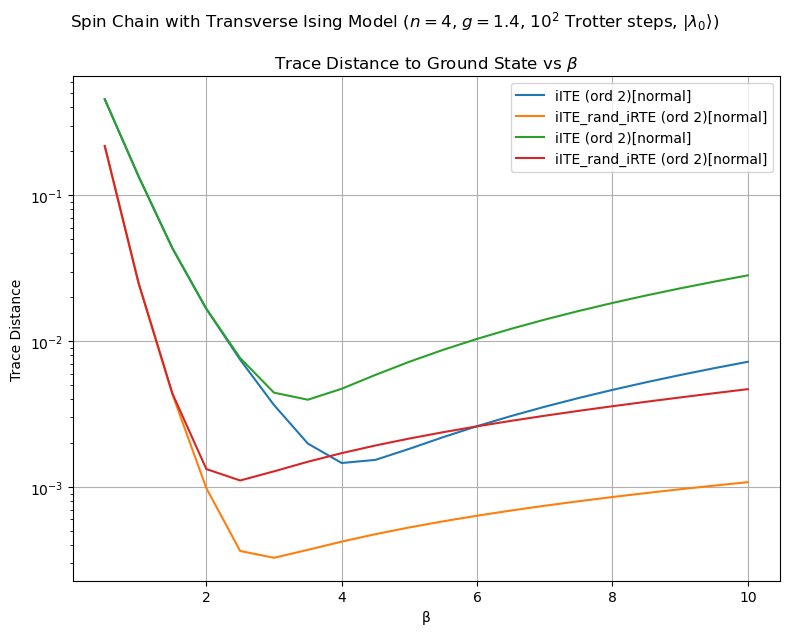

In [62]:

fig, (ax1) = plt.subplots(1, 1, figsize=(8,6))
args = data, method_names, betas
# energy_plot(ax1, *args)
# trd_plot(ax1, *args)

sorted_keys = sorted(memory.keys(), key=lambda x: x[1])
for k in sorted_keys:
    steps, order, aux = k
    # if steps == 0: continue
    label = "(Ideal)" if steps == 0 else f"(ord {order})"
    label += f"[{aux}]"
    trd_plot(ax1, memory[k], method_names, betas, suffix=label, linestyle='--' if steps == 0 else '-')
# spincov_plot(ax3, *args)
# spincov_rel_err_plot(ax3, *args)

plt.tight_layout()
plt.suptitle(rf'Spin Chain with Transverse Ising Model ($n = {n}$, $g = {g}$, '+rf'$10^{{{np.log10(steps):.0f}}}$ Trotter steps, '+ rf'$|\lambda_{excited_ind}\rangle$)', y=1.05)
plt.show()

50
50
100
100
150
150
200
200
250
250
300
300
350
350
400
400
450
450
500
500
50
11700
1950
700
350
200
150
100
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
100
150
200
350
700
1950
11700
100
100
100
100
100
100
150
150
250
300
450
750
1450
3900
23400
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
23400
3900
1450
750
450
300
250
150
150
100
100
100
100
100
100
150
150
150
150
150
150
100
100
100
100
100
100
100
100
100
46800
7850
2950
1500
950
650
500
350
300
250
250
200
200
200
200
200
200
200
200
250
250
300
350
500
650
950
1500
2950
7850
46800
100
100
100
100
100
100
100
100
100
150
150
150
150
150
150
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
50
100
100
100
100
100
100
150
150
150
150
150
150
150
150
150
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
1

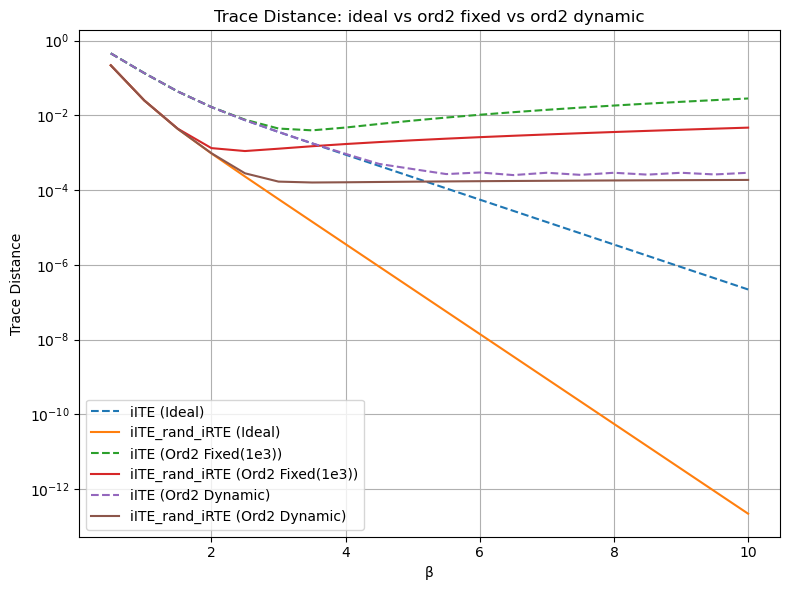

In [63]:
# Final comparison: 6 curves = {ideal, ord2 fixed(1e3), ord2 dynamic} x {iITE, iITE_rand_iRTE}
def run_case(label, steps, order, dynamic_steps=False):
    hamil = Hamiltonian(H, Hs, steps=steps, order=order, dynamic_steps=dynamic_steps, max_dt=1.0, dynamic_order=2)
    Delta = hamil.lam[1] - hamil.lam[0]

    methods = [
        ('iITE', lambda *args: outer(hamil.iITE(*args, method='direct'))),
        ('iITE_rand_iRTE', lambda psi0, beta: hamil.iITE_rand_iRTE(
            psi0, beta, M=int(1e3),
            sample=stats.norm(loc=0, scale=np.sqrt(2*beta/Delta)).rvs,
            pdf=stats.norm(loc=0, scale=np.sqrt(2*beta/Delta)).pdf,
            method='integrate', epsrel=1e-6,
        )),
    ]

    out = {}
    for mn, method in methods:
        trd_runs = []
        for psi0 in psi0s:
            trd_runs.append([trdist(method(psi0, beta), outer(hamil.U[:, excited_ind])) for beta in betas])
        out[mn] = np.array(trd_runs)
    return out

cases = [
    ('Ideal', 0, 0, False),
    ('Ord2 Fixed(1e3)', int(50), 2, False),
    ('Ord2 Dynamic', int(50), 2, True),
]

results = {name: run_case(name, s, o, dyn) for name, s, o, dyn in cases}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for name, *_ in cases:
    for mn, ls in [('iITE', '--'), ('iITE_rand_iRTE', '-')]:
        y = np.mean(results[name][mn], axis=0)
        ax.plot(betas, y, ls, label=f'{mn} ({name})')

ax.set_xlabel('β')
ax.set_ylabel('Trace Distance')
ax.set_yscale('log')
ax.set_title('Trace Distance: ideal vs ord2 fixed vs ord2 dynamic')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()